![banner-pdi](https://user-images.githubusercontent.com/58775072/141189378-b5df3287-e8c0-48a1-ad11-825ba317463b.png)

## Universidade Federal de Campina Grande (UFCG)
## Centro de Engenharia Elétrica e Informática (CEEI) 
## Disciplina: Int. ao Processamento de Imagem Digital e Visão Computacional
## Professora: Luciana Ribeiro Veloso
## Aluno(a): Keviny Ryan Menezes Dantas

## Observações
***

1. Os arquivos de laboratório devem ser salvos seguindo o seguinte padrão: `lab-x-nome-sobrenome.ipynb`.
2. Não esqueça de colocar o seu nome no cabeçalho acima.
3. Não altere a ordem das células e realize as implementações somente nos campos específicados.  
4. Ao longo do laboratório será solicitado perguntas teóricas relativas aos assuntos das aulas da disciplina e implementações de código utilizando a linguagem de programação Python. 
5. As células de implementação com código serão indicadas pelos seguintes comentários: `# IMPLEMENTE O SEU CÓDIGO AQUI`.
6. Para editar uma célula de texto, basta clicar duas vezes com o cursos do mouse para editar, e `Ctrl + Enter` para finalizar a edição. 
7. Para rodar as células com os códigos desenvolvidos, digite `Ctrl + Enter` ou clique em `Run` no menu do Jupyter.
8. Dúvidas, problemas de execução de código ou dificuldades com a linguagem de programação Python devem ser feitas durante as aulas de laboratório, encaminhadas para o grupo de WhatsApp da turma ou fórum do PVAE da disciplina.
9. Os laboratórios devem ser enviados nos campos especificados pelo PVAE. ATENTE-SE AOS PRAZOS DE ENTREGA!

# <span style='color:red'>Laboratório 4: Morfologia Matemática</span>
***

### Importação dos Pacotes

In [1]:
import os                            # operational system para manipulação de arquivos
import cv2                           # opencv para manipulação de imagens
import numpy as np                   # numpy para manipulação de matrizes e arrays
import matplotlib.pyplot as plt      # pyplot para plotagem de gráficos e imagens
import skimage.morphology            # scikit-image para produzir elementos estruturantes
import urllib.request as url         # urllib para baixar arquivos via HTTPS
import zipfile                       # zipfile para lidar com pastas compactadas

In [2]:
# baixando as imagens de referência
url.urlretrieve('https://github.com/Alyssonmach/pdi-labs/raw/main/imagens.zip', 'imagens.zip')
with zipfile.ZipFile('imagens.zip', 'r') as zip_ref:
    zip_ref.extractall('')

### Operações Lógicas em Imagens Binárias

É possível submeter imagens a operações lógicas de modo a obter novas imagens. Nesse contexto, a biblioteca OpenCV disponibiliza um conjunto de funções para implementação dessas operações:

1. AND: **C = A $\cap$ B**   
    * `C = cv2.bitwise_and( A, B )`
2. OR: $C = A \cup B$   
    * `C = cv2.bitwise_or( A, B )`
3. XOR: $C = A \oplus B$   
    * `C = cv2.bitwise_xor( A, B )`
4. Not: $C = \overline{A}$   
    * `C = ~A`
5. Diferença: $C = A \cap \overline{B} $   
    *  `C = A - B` 
    
    
**Obs:** a função `cv2.threshold( src_img, limiar, vmax, cv2.THRESH_BINARY)` pode ser utilizada para binarizar imagens de tipo `uint`, sendo necessário informar o limiar de binarização e o valor do nível alto. A função retorna o limiar utilizado e a imagem binarizada, com pixels de nível alto setados para `vmax` e os demais para 0.

 ## <span style='color:blue'>Questão 1: [Valor da Questão: 1.0][Taxa de acerto: x.x]</span>

* Carregue as imagens “**A.tif**” e “**B.tif**”. Faça uma binarização e realize as operações abaixo. Plote os resultados e os comente.

    * 1. $A$  
    * 2. $B$  
    * 3. $C = A \cap B$ 
    * 4. $D = A - B$   
    * 5. $E = \overline{A}$    
    * 6. $F = \overline{B}$  
    * 7. $G = A \cup B$  
    * 8. $H = B - A$ 

Text(0.5, 0, 'Dimensões (313, 316)')

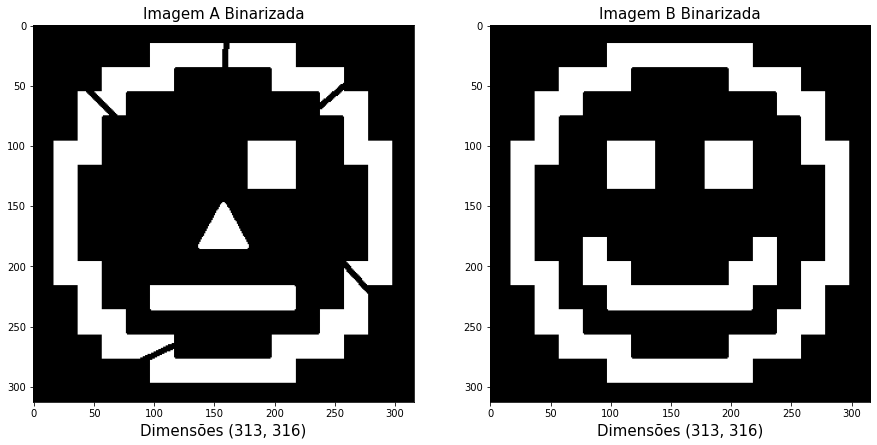

In [3]:
ima = cv2.imread('imagens/A.tif')
ima = cv2.cvtColor(ima, cv2.COLOR_BGR2GRAY)
imb = cv2.imread('imagens/B.tif')
imb = cv2.cvtColor(imb, cv2.COLOR_BGR2GRAY)
 
# aplicando a binarização nas imagens carregadas
ima_bin = cv2.threshold( ima, 127.5, 255, cv2.THRESH_BINARY)[1]
imb_bin = cv2.threshold( imb, 127.5, 255, cv2.THRESH_BINARY)[1]

fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (15, 15))

# primeira figura da subplotagem
axs[0].imshow(ima_bin, cmap = 'gray', vmin = np.min(ima_bin), vmax = np.max(ima_bin))
axs[0].set_title('Imagem A Binarizada', size = 15)
axs[0].set_xlabel('Dimensões ' + str(ima_bin.shape), size = 15)

# segunda figura da subplotagem
axs[1].imshow(imb_bin, cmap = 'gray', vmin = np.min(imb_bin), vmax = np.max(imb_bin))
axs[1].set_title('Imagem B Binarizada', size = 15)
axs[1].set_xlabel('Dimensões ' + str(imb_bin.shape), size = 15) 

Text(0.5, 0, 'Dimensões (313, 316)')

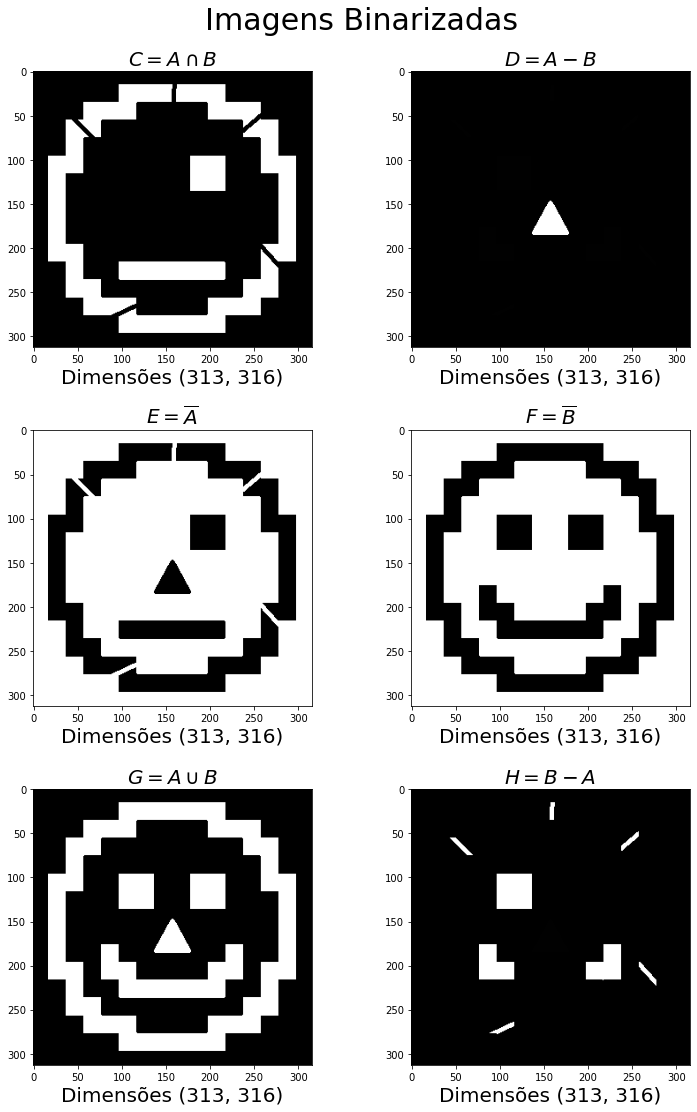

In [4]:
# IMPLEMENTE SEU CÓDIGO AQUI --> QUESTÃO 1
# operação lógica 3
imc = cv2.bitwise_and( ima, imb )
# operação lógica 4
imd = ima - imb
# operação lógica 5
ime = ~ima
# operação lógica 6
imf = ~imb
# operação lógica 7
img = cv2.bitwise_or( ima, imb )
# operação lógica 8
imh = imb - ima

fig, axs = plt.subplots(nrows = 3, ncols = 2, figsize = (15, 15))
plt.subplots_adjust(left = 0, bottom = 0, right = 0.7, top = 0.92, wspace = 0, hspace = 0.3)
fig.suptitle('Imagens Binarizadas', size = 30, x = 0.35) 

# primeira figura da subplotagem
axs[0,0].imshow(imc, cmap='gray', vmin = np.min(imc), vmax = np.max(imc))
axs[0,0].set_title('$C = A \cap B$', size = 20)
axs[0,0].set_xlabel('Dimensões ' + str(imc.shape), size = 20)

# segunda figura da subplotagem
axs[0,1].imshow(imd, cmap='gray', vmin = np.min(imd), vmax = np.max(imd))
axs[0,1].set_title('$D = A - B$ ', size = 20)
axs[0,1].set_xlabel('Dimensões ' + str(imd.shape), size = 20)

# terceira figura da subplotagem
axs[1,0].imshow(ime, cmap='gray', vmin=np.min(ime), vmax=np.max(ime))
axs[1,0].set_title('$E = \overline{A}$', size=20)
axs[1,0].set_xlabel('Dimensões ' + str(ime.shape), size=20)

# quarta figura da subplotagem
axs[1,1].imshow(imf, cmap='gray', vmin = np.min(imf), vmax = np.max(imf))
axs[1,1].set_title('$F = \overline{B}$', size = 20)
axs[1,1].set_xlabel('Dimensões ' + str(imf.shape), size = 20)

# quinta figura da subplotagem
axs[2,0].imshow(img, cmap='gray', vmin = np.min(img), vmax = np.max(img))
axs[2,0].set_title('$G = A \cup B$', size = 20)
axs[2,0].set_xlabel('Dimensões ' + str(img.shape), size = 20)

# sexta figura da subplotagem
axs[2,1].imshow(imh, cmap = 'gray', vmin = np.min(imh), vmax = np.max(imh))
axs[2,1].set_title('$H = B - A$', size = 20)
axs[2,1].set_xlabel('Dimensões ' + str(imh.shape), size = 20) 

## <span style='color:green'>Respostas da Questão 1:</span>

* As imagens resultantes das operações saíram de acordo, por exemplo a imagem G, ela saiu com todos os pixels brancos representados, sendo por consequência a imagem b, pois de acorco com a lógica ele vai pegar todas as informações, pela a própria funcionalidade da OR, onde se tiver um pixel igual ela irá pegar a imagem com maior informação, funcionamento da or: 0 OR 0 = 0 0 OR 1 = 1, 1 OR 0 = 1, 1 OR 1 = 1. Assim como também a imagem C originada da and seguiu o funcionamento de acordo: and: 0 and 1 = 0; 1 and 0 = 0; 1 and 1 = 1.

## <span style='color:blue'>Questão 2: [Valor da Questão: 1.0][Taxa de acerto: x.x]</span>

* O código abaixo aplica uma das máscaras binárias da questão anterior sobre uma imagem. Com relação à imagem resultante, responda:
 * (a) Qual o efeito de aplicar uma máscara binária sobre uma imagem?
 * (b) Cite pelo menos duas possíveis aplicações dessa operação. Qual o papel das máscaras nessas aplicações?
 * (c) Tendo em vista a quantidade de tons de cinza na máscara, qual a importância do tipo de interpolação utilizado?  

Text(0.5, 1.0, 'Imagem Resultante')

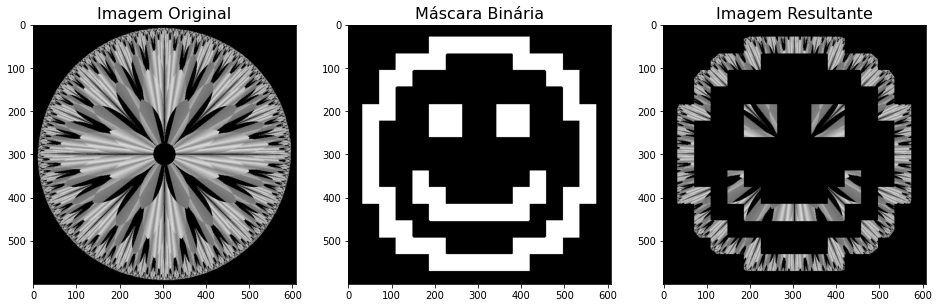

In [5]:
# imagem mandala
mandala = cv2.imread( os.path.join(".", "imagens", "mandala.jpg"), 0 )
H, W = mandala.shape

# imagem b
B = cv2.imread( os.path.join(".", "imagens", "B.tif"), 0 )
_, B = cv2.threshold(B, 127, 255, cv2.THRESH_BINARY)
B_resized = cv2.resize(B, (W, H), interpolation = cv2.INTER_NEAREST)

# imagem d
combined = cv2.bitwise_and( mandala, B_resized )

# plotagem
fig, axs = plt.subplots(nrows = 1, ncols = 3, figsize=(16, 8))

# primeira subfigura da primeira linha
axs[0].imshow(mandala, vmin=0, vmax=255, cmap="gray")
axs[0].set_title("Imagem Original", fontsize = 16)

# segunda subfigura da primeira linha
axs[1].imshow(B_resized, vmin=0, vmax=255, cmap="gray")
axs[1].set_title("Máscara Binária", fontsize = 16)

# terceira subfigura da primeira linha
axs[2].imshow(combined, vmin=0, vmax=255, cmap="gray")
axs[2].set_title("Imagem Resultante", fontsize = 16)

## <span style='color:green'>Respostas da Questão 02:</span>

* (a) Ao verificar o resultado se faz visível a utilização de uma operação "AND", pelo o fato da imagem resultante ser uma imagem gerada pela a quantidade de pixels que as imagens da operação possuem em comum, e recebendo a coloração da imagem 1 nos pixeis que formavam a imagem, como se fosse uma substituição da parte branca pela a coloração.

* (b) A aplicação desse tipo de mascaramento e manipulação cobrirá toda a imagem e deixará visíveis apenas as áreas específicas que serão analisadas a olho nu, de modo que o observador terá menos informações para prestar atenção. Facilitando a percepção de alguns detalhes sem usar IA. Esse tipo de máscara pode ser usado para treinar uma IA para encontrar pequenos detalhes ou informações subliminares ocultas em uma imagem, por exemplo, imagine uma máscara toda branca com pequenas informações em tons escuros fazendo algo semelhante ao que é feito neste código de exemplo , esse pequeno pedaço de informação ficará "escondido" na imagem, e a IA pode ser treinada para encontrar certos tipos de padrões presentes na imagem ou para verificar a arte, a IA treinada para encontrar padrões de pintor por meio deste aplicativo pode facilitar a autenticação O processo é de várias maneiras, IA poderá ser adaptada para treinamento para comparação de rostos de câmeras com algum banco de dados de foto ou etc.

* (c) Essa aproximação de valores mais discretos deve ter o mínimo de erro possível, e torna-se fundamental aplicar o tipo correto de interpolação para tais aplicações a fim de eliminar falhas de aplicação e fazer com que as máscaras funcionem com sucesso, pois a operação AND usado assume o valor de zero para quaisquer zeros envolvidos.

### Transformações Lineares

Também é possível realizar transformações lineares como rotação e translação com o OpenCV. Para isso, faz-se uso da função **warpAffine**.

`dst_img = cv2.warpAffine(src_img, M, (cols, rows))`

Descrição:  
* **dst_img** representa a imagem de saída;
* **src_img** representa a imagem de entrada;
* **M** corresponde à matriz de transformação utilizada;
* **rows** corresponde ao número de linhas da imagem;
* **cols** corresponde ao número de colunas da imagem;

Alguns exemplos de transformações que podem ser produzidas a partir desta função são:

1. Translações:
    * Para transladar a imagem Tx pixels para a direita e Ty pixels para baixo, faz-se uso de uma matriz com forma: 
    * **M = [ [1, 0, Tx], [0, 1, Ty] ]**
2. Rotações:
    * A matriz de transformação para uma rotacão de $\theta$ graus com relação ao ponto (Px, Py) pode ser obtida utilizando a função **getRotationMatrix2D**: 
    * `M = cv2.getRotationMatrix2D( (Px, Py), $\theta$, scale)`
3. Reflexão:
    * A imagem pode ser refletida utilizando as seguintes matrizes: 
    * **M = [ [-1, 0, cols-1], [0, 1, 0] ]**
    * **M = [ [1, 0, 0], [0, -1, rows-1] ]**

## <span style='color:blue'>Questão 3: [Valor da Questão: 1.0][Taxa de acerto: x.x]</span>

* (a) O código abaixo implementa algumas das transformações descritas. Comente todas as linhas desse código e explique o que o programa faz.
* (b) Que transformações são implementadas pelas matrizes Ma, Mb, Mc e Md?
* (c) As imagens 2 e 4 são diferentes apesar de terem sofrido as mesmas transformações. Por que isso aconteceu?

Text(0.5, 1.0, 'Imagem 6')

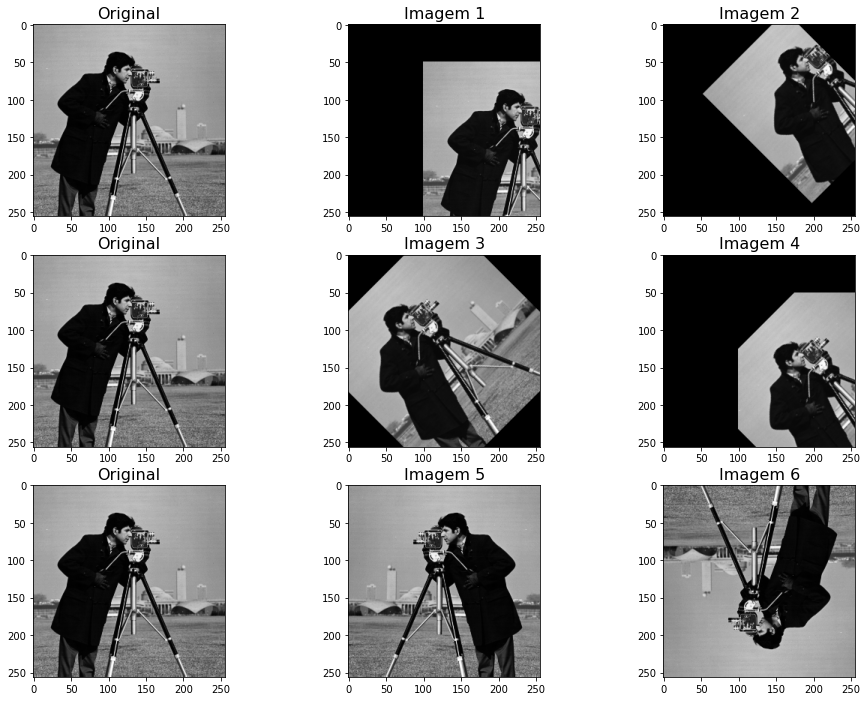

In [6]:
# COMENTE AS LINHAS DE CÓDIGO ABAIXO --> QUESTÃO 3 - LETRA (a)

Tx    = 100 #Número de pixels das transformações no eixo X
Ty    =  50 #Número de pixels das transformações no eixo Y

theta =  45 #Angulação empregada na rotação de imagens

src_img = cv2.imread(os.path.join(".", "imagens", "cameraman.jpg"), 0) #Leitura da imagem em tons de cinza
rows, cols = src_img.shape #Modo de adquirir o número de colunas e linhas presentes na imagem.

Ma = np.array( [ [1, 0, Tx], [0, 1, Ty] ], dtype=np.float32 ) #Matriz Utilizada para translar a imagem
Mb = cv2.getRotationMatrix2D( (cols/2, rows/2),  theta , 1) #Matriz para emprego da rotação de acordo com uma respectiva coluna e linha
Mc = np.array( [[-1, 0, cols-1], [0, 1, 0]], dtype = np.float32 ) #matriz para reflexão das colunas
Md = np.array( [[1, 0, 0], [0, -1, rows-1]], dtype = np.float32 ) # Matriz para reflexão das linhas

fig, axs = plt.subplots(nrows = 3, ncols = 3, figsize=(16, 12)) # plot e configuração de ordem e tamanho dos resultados

#Imprime imagem Original e título
axs[0][0].imshow(src_img, cmap="gray") 
axs[0][0].set_title("Original", fontsize = 16)


dst_img = cv2.warpAffine(src_img, Ma, (cols, rows)) # translação com a Matriz Ma

#Imprime imagem resultante da aplicação da translação e título
axs[0][1].imshow(dst_img, cmap="gray")
axs[0][1].set_title("Imagem 1", fontsize = 16)

dst_img = cv2.warpAffine(dst_img, Mb, (cols, rows)) #Efetua uma rotação da imagem translada com a matriz Mb

#Imprime imagem resultante da aplicação da rotação da imagem transladada e título
axs[0][2].imshow(dst_img, cmap="gray")
axs[0][2].set_title("Imagem 2", fontsize = 16)

#Imprime imagem Original e título
axs[1][0].imshow(src_img, cmap="gray")
axs[1][0].set_title("Original", fontsize = 16)

dst_img = cv2.warpAffine(src_img, Mb, (cols, rows)) # Rotação com a Matriz Mb

#Imprime imagem resultante da aplicação da rotação e título
axs[1][1].imshow(dst_img, cmap="gray")
axs[1][1].set_title("Imagem 3", fontsize = 16)

dst_img = cv2.warpAffine(dst_img, Ma, (cols, rows)) # Transalação com a matriz Ma

#Imprime imagem resultante da aplicação da translação da imagem de rotação e título
axs[1][2].imshow(dst_img, cmap="gray")
axs[1][2].set_title("Imagem 4", fontsize = 16)

#Imprime imagem Original e título
axs[2][0].imshow(src_img, cmap="gray") 
axs[2][0].set_title("Original", fontsize = 16)

dst_img = cv2.warpAffine(src_img, Mc, (cols, rows)) # Reflexão da imagem com a Matriz Mc

#Imprime imagem resultante da aplicação da reflexão e título
axs[2][1].imshow(dst_img, cmap="gray")
axs[2][1].set_title("Imagem 5", fontsize = 16)

dst_img = cv2.warpAffine(dst_img, Md, (cols, rows)) #Reflexão da imagem com a mAtriz Md

# Imprime imagem resultante da aplicação da reflexão de linhas da imagem que já foi efetuada a reflexão de colunas
axs[2][2].imshow(dst_img, cmap="gray")
axs[2][2].set_title("Imagem 6", fontsize = 16)

## <span style='color:green'>Respostas da Questão 03:</span>

* (b) A Matriz Ma efetua um processo de translação usando de base Tx para a direita e Ty para baixo, A matriz Mb efetua a rotação da imagem através do theta em um ponto específico usando de base o ponrto definido por (cols/2, rows/2), As matriz Mc e Md efetuam o processo de reflexão, sendo uma reflexão das colunas e outra das linhas, respectivamente.
* (c) A diferença é explicada pela a ordem da operação realizada, na imagem 2 foi efetuada uma translação com a Matriz Ma e depois a rotação com a matriz Mb sobre o resutado da translação, na 4 foi efetuado de forma inversa, gerando uma rotação com a matriz Mb e uma transtalão com a matriz Ma sobre a imagem rotacionada com a matriz Mb.

## <span style='color:blue'>Questão 4: [Valor da Questão: 1.5][Taxa de acerto: x.x]</span>

* Abra a imagem "**Seta.tif**", realize operações abaixo e comente os resultados obtidos.
 * Translação de -50 pixels na horizontal e   0 pixels na vertical.
 * Translação de 125 pixels na horizontal e -75 pixels na vertical.
 * Reflexão horizontal.
 * Reflexão vertical.
 * Rotação de -25° com relação ao ponto (x =  59, y =  78) e escala   1.
 * Rotação de  25° com relação ao ponto (x = 118, y = 118) e escala   3.
 * Rotação de  25° com relação ao ponto (x = 118, y = 118) e escala 1/3.
 * Rotação de   0° com relação ao ponto (x =  59, y =  59) e escala 1/4.

In [7]:
def make_translation(input_image, tx, ty):
    '''função auxiliar para realizar transformação linear de translação'''
    
    mat_trans = np.array([ [1, 0, tx], [0, 1, ty] ], dtype=np.float32)
    
    return cv2.warpAffine(input_image, mat_trans, input_image.shape) 

def make_rotation(input_image, x, y, theta, scale):
    '''função auxiliar para realizar transformação linear de rotação'''
    
    mat_trans = cv2.getRotationMatrix2D((x, y),  theta , scale)
    
    return cv2.warpAffine(input_image, mat_trans, input_image.shape)  

def make_reflection(input_image, label = 'x'):
    '''função auxiliar para realizar transformação linear de reflexão '''
    
    rows, cols = input_image.shape[0], input_image.shape[1]
    
    if label == 'y': mat_trans = np.array([[1, 0, 0], [0, -1, rows-1]], dtype = np.float32)
    else: mat_trans = np.array([[-1, 0, cols-1], [0, 1, 0]], dtype = np.float32)
        
    return cv2.warpAffine(input_image, mat_trans, input_image.shape)

Text(0.5, 1.0, 'IMG 08')

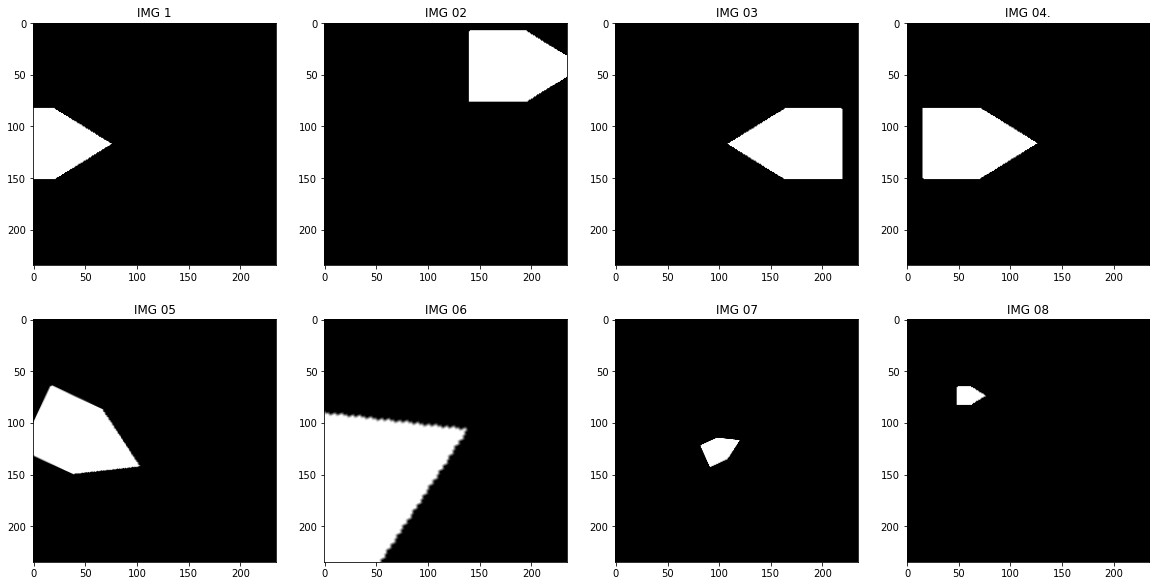

In [8]:
# IMPLEMENTE SEU CÓDIGO AQUI --> QUESTÃO 4

img = cv2.imread(os.path.join(".", "imagens", "Seta.tif"), 0)
rows, cols = img.shape

fig, axs = plt.subplots(nrows = 2, ncols = 4, figsize=(20, 10))

#IMAGEM 01: Translação de -50 pixels na horizontal e 0 pixels na vertical.
img_t1 = make_translation(img, -50, 0)
#IMAGEM 02: Translação de 125 pixels na horizontal e -75 pixels na vertical.
img_t2 = make_translation(img, 125, -75)
#IMAGEM 03: Reflexão horizontal.
img_rfh = make_reflection(img, label = 'x')
#IMAGEM 04: Reflexão vertical.
img_rfv = make_reflection(img, label = 'y')
#IMAGEM 05: Rotação de -25° com relação ao ponto (x = 59, y = 78) e escala 1.
img_r1 = make_rotation(img, 59, 78, -25, 1)
#IMAGEM 06: Rotação de 25° com relação ao ponto (x = 118, y = 118) e escala 3.
img_r2 = make_rotation(img, 118, 118, 25, 3)
#IMAGEM 07: Rotação de 25° com relação ao ponto (x = 118, y = 118) e escala 1/3.
img_r3 = make_rotation(img, 118, 118, 25, 1/3)
#IMAGEM 08: Rotação de 0° com relação ao ponto (x = 59, y = 59) e escala 1/4.
img_r4 = make_rotation(img, 59, 59, 0, 1/4)

axs[0,0].imshow(img_t1, vmin=0, vmax=255, cmap="gray")
axs[0,0].set_title("IMG 1", fontsize = 12)

axs[0,1].imshow(img_t2, vmin=0, vmax=255, cmap="gray")
axs[0,1].set_title("IMG 02", fontsize = 12)

axs[0,2].imshow(img_rfh, vmin=0, vmax=255, cmap="gray")
axs[0,2].set_title("IMG 03", fontsize = 12)

axs[0,3].imshow(img_rfv, vmin=0, vmax=255, cmap="gray")
axs[0,3].set_title("IMG 04.", fontsize = 12)

axs[1,0].imshow(img_r1, vmin=0, vmax=255, cmap="gray")
axs[1,0].set_title("IMG 05", fontsize = 12)

axs[1,1].imshow(img_r2, vmin=0, vmax=255, cmap="gray")
axs[1,1].set_title("IMG 06", fontsize = 12)

axs[1,2].imshow(img_r3, vmin=0, vmax=255, cmap="gray")
axs[1,2].set_title("IMG 07", fontsize = 12)

axs[1,3].imshow(img_r4, vmin=0, vmax=255, cmap="gray")
axs[1,3].set_title("IMG 08", fontsize = 12)

## <span style='color:green'>Respostas da Questão 4:</span>

* Podemos averiguar que as imagens resultantes estão de acordo com o esperado, pelo o que foi trabalhado até aqui!

### Dilatação e Erosão

A partir de um elemento estruturante é possível utilizar funções do OpenCV para realizar as transformações morfológicas de erosão (1) e dilatação (2). A sintaxe das funções é: 

 1. `dst_img = cv2.erode( src_img, kernel, iterations = 1 )`    
 2. `dst_img = cv2.dilate( src_img, kernel, iterations = 1 )`   

* **Descrição:**  
    * **dst_img** representa a imagem de saída;
    * **src_img** representa a imagem de entrada;
    * **kernel** representa o elemento estruturante;
    * **iterations** corresponde ao número de vezes que a operação deve ser repetida.

Elementos estruturantes podem ser produzidos a partir de arrays do numpy.

## <span style='color:blue'>Questão 5: [Valor da Questão: 1.0][Taxa de acerto: x.x]</span>

* Carregue a imagem "**text.tif**" e utilize o elemento estruturante abaixo para produzir uma versão dilatada da imagem e outra versão erodida. Comente os resultados encontrados.
    * `kernel = np.array([[1, 0, 1], [0, 1, 0], [1, 0, 1]], dtype = np.uint8)`

Text(0.5, 1.0, 'Erosão da text.tif ')

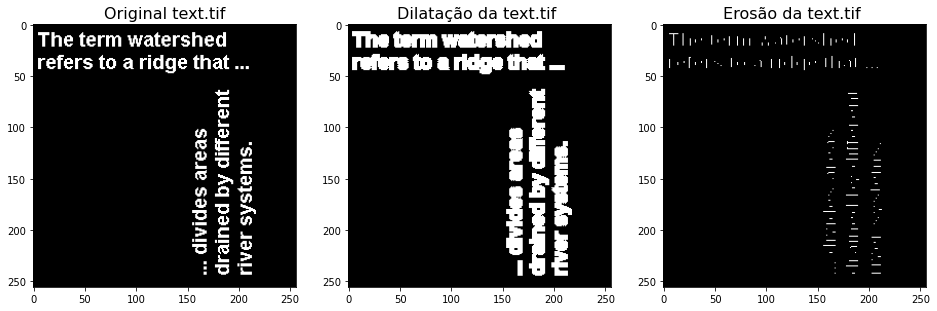

In [9]:
## IMPLEMENTE SEU CÓDIGO AQUI --> QUESTÃO 5

img = cv2.imread(os.path.join(".", "imagens", "text.tif"), 0)

fig, axs = plt.subplots(nrows = 1, ncols = 3, figsize=(16, 8))

#Kernel orientado 
kernel = np.array([[1, 0, 1], [0, 1, 0], [1, 0, 1]], dtype = np.uint8)

#Processo para gerar imagem com dilatada
img_de_dilatacao = cv2.dilate(img, kernel, iterations = 1 )

#Processo para gerar imagem com erosão
img_de_erosao = cv2.erode(img, kernel, iterations = 1 )

#Imprime a imagem "text.tif"
axs[0].imshow(img, vmin=0, vmax=255, cmap="gray")
axs[0].set_title("Original text.tif", fontsize = 16)

axs[1].imshow(img_de_dilatacao, vmin=0, vmax=255, cmap="gray")
axs[1].set_title("Dilatação da text.tif ", fontsize = 16)

axs[2].imshow(img_de_erosao, vmin=0, vmax=255, cmap="gray")
axs[2].set_title("Erosão da text.tif ", fontsize = 16)


## <span style='color:green'>Respostas da Questão 5:</span>

* Na Imagem dilatada vemos um resultado de uma imagem borrada e expandida, não permitindo a visualização de forma eficaz, tal desfoco se assemelha ao resultado de imagens da dilatação da pupila.

* Na imagem resultada da erosão, possuem falhas advindas da erosão que não permite a visualização com qualidade por falhas.

Elementos estruturantes também podem ser produzidos pela função **getStructuringElement** do OpenCV:

 * `kernel = cv2.getStructuringElement( FLAG, (W,H) )`

* **Descrição:**
    * **kernel** representa o elemento estruturante;
    * **(W, H)** é uma tupla com as dimensões do elemento estruturante;
    * **FLAG** é um parâmetro que indica o tipo de elemento estruturante produzido, pode ser:
        * **cv2.MORPH_RECT** produz um elemento retangular;
        * **cv2.MORPH_ELLIPSE** produz um elemento elíptico;
        * **cv2.MORPH_CROSS** produz um elemento em forma de cruz;

Text(0.5, 1.0, 'cv2.MORPH_CROSS')

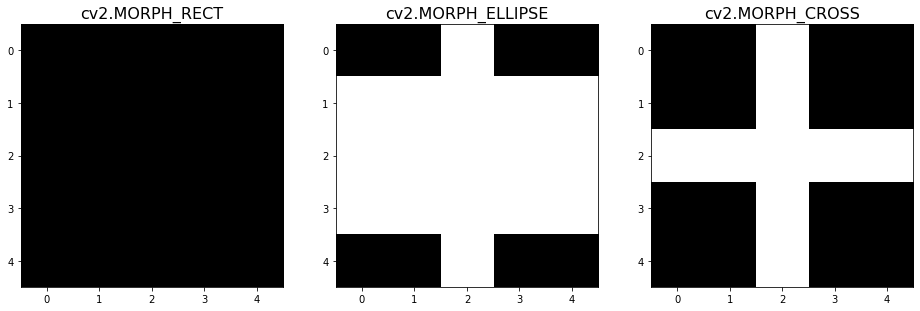

In [10]:
H, W = 5, 5

# plots
fig, axs = plt.subplots(nrows = 1, ncols = 3, figsize = (16, 12))

# primeira Subfigura da primeira linha
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (W, H))
axs[0].imshow(kernel, cmap = "gray")
axs[0].set_title("cv2.MORPH_RECT", fontsize = 16)

# segunda Subfigura da primeira linha
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (W, H))
axs[1].imshow(kernel, cmap = "gray")
axs[1].set_title("cv2.MORPH_ELLIPSE", fontsize = 16)

# terceira Subfigura da primeira linha
kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (W, H))
axs[2].imshow(kernel, cmap = "gray")
axs[2].set_title("cv2.MORPH_CROSS", fontsize = 16)

Ou ainda utilizando as funções do Scikit-Image:

 * `kernel = skimage.morphology.square( H )`
 * `kernel = skimage.morphology.rectangle( H, W )`
 * `kernel = skimage.morphology.diamond( H )`
 * `kernel = skimage.morphology.disk( R )`
 * `kernel = skimage.morphology.octagon( M, N )`
 * `kernel = skimage.morphology.star( A)`

Text(0.5, 1.0, 'Star')

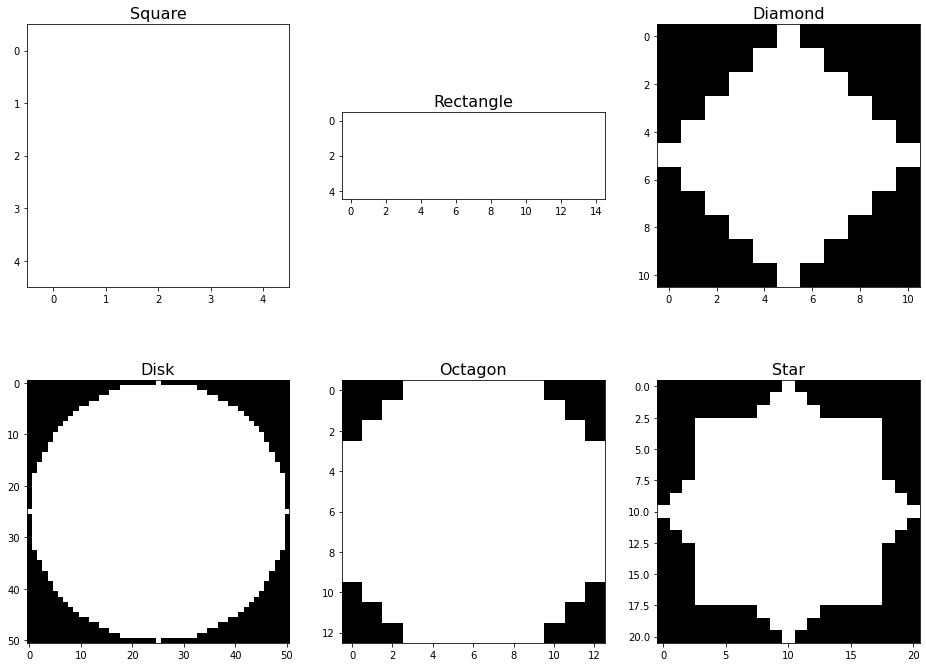

In [11]:
H =  5 # altura do quadrado/retângulo e lado do diamante
W = 15 # largura do retângulo
R = 25 # raio do disco
M =  7 # comprimento dos lados retos do octágono
N =  3 # comprimento dos lados inclinados do octágono
A =  7 # variável que controla o tamanho da estrela, o quadrado que a contém tem lado H = 2 * a + 1 + 2 * floor(a / 2) 

# plots
fig, axs = plt.subplots(nrows = 2, ncols = 3, figsize=(16, 12))

# primeira Subfigura da primeira linha 
kernel = skimage.morphology.square(H)
axs[0][0].imshow(kernel, vmin = 0, vmax = 1, cmap = "gray")
axs[0][0].set_title("Square", fontsize = 16)

# segunda Subfigura da primeira linha
kernel = skimage.morphology.rectangle(H, W)
axs[0][1].imshow(kernel, vmin = 0, vmax = 1, cmap = "gray")
axs[0][1].set_title("Rectangle", fontsize = 16)

# terceira Subfigura da primeira linha
kernel = skimage.morphology.diamond(H)
axs[0][2].imshow(kernel, vmin = 0, vmax = 1, cmap = "gray")
axs[0][2].set_title("Diamond", fontsize = 16)

# primeira Subfigura da segunda linha
kernel = skimage.morphology.disk(R)
axs[1][0].imshow(kernel, vmin = 0, vmax = 1, cmap = "gray")
axs[1][0].set_title("Disk", fontsize = 16)

# segunda Subfigura da segunda linha
kernel = skimage.morphology.octagon(M, N)
axs[1][1].imshow(kernel, vmin = 0, vmax = 1, cmap = "gray")
axs[1][1].set_title("Octagon", fontsize = 16)

# terceira Subfigura da segunda linha
kernel = skimage.morphology.star(A)
axs[1][2].imshow(kernel, vmin = 0, vmax = 1, cmap = "gray")
axs[1][2].set_title("Star", fontsize = 16)

Text(0.5, 1.0, 'Linha Vertical de 12 pontos')

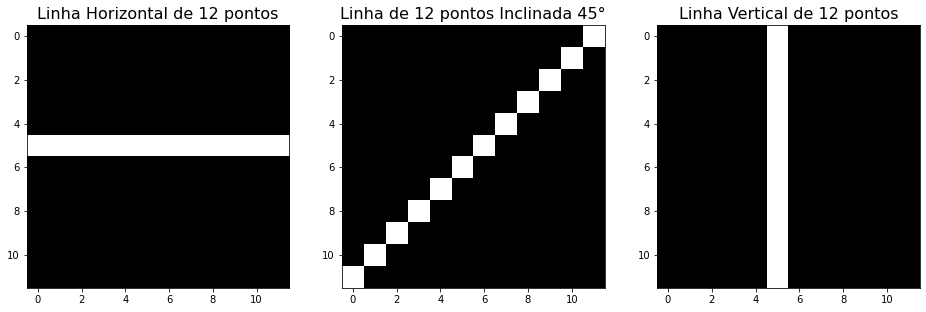

In [12]:
# Elemento estruturante correspondente a uma linha horizontal
k_size = 12
k_mid  = (k_size - 1) // 2
orig_kernel  = np.zeros( (k_size, k_size), dtype = np.uint8 )
orig_kernel[k_mid, :] = 1

# Matriz de rotação para 45°
M = cv2.getRotationMatrix2D( (3, 3),  45 ,   1)

# Plots
fig, axs = plt.subplots(nrows = 1, ncols = 3, figsize=(16, 12))

# Primeira Subfigura da primeira linha
axs[0].imshow(orig_kernel, cmap="gray")
axs[0].set_title("Linha Horizontal de {} pontos".format(k_size), fontsize = 16)

# Segunda Subfigura da primeira linha
kernel = np.zeros_like( orig_kernel )
for i in range(k_size):
    kernel[k_size - i - 1, i] = 1

axs[1].imshow(kernel, cmap="gray")
axs[1].set_title("Linha de {} pontos Inclinada 45°".format(k_size), fontsize = 16)

# Terceira Subfigura da primeira linha
kernel = np.zeros_like( orig_kernel )
kernel[:, k_mid] = 1
axs[2].imshow(kernel, cmap="gray")
axs[2].set_title("Linha Vertical de {} pontos".format(k_size), fontsize = 16)

## <span style='color:blue'>Questão 6: [Valor da Questão: 1.0][Taxa de acerto: x.x]</span>

* Usando as funções mostradas, gere os seguintes elementos estruturantes para dilatar a imagem 'text.tif'. Mostre as imagens resultantes e comente os resultados encontrados.
 * Disco de raio 9;
 * Estrela com A = 13;
 * Linha vertical de 11 pontos de tamanho;
 * Linha vertical de 9 pontos de tamanho;

Text(0.5, 1.0, 'Dilatação com a linha de 9 pontos')

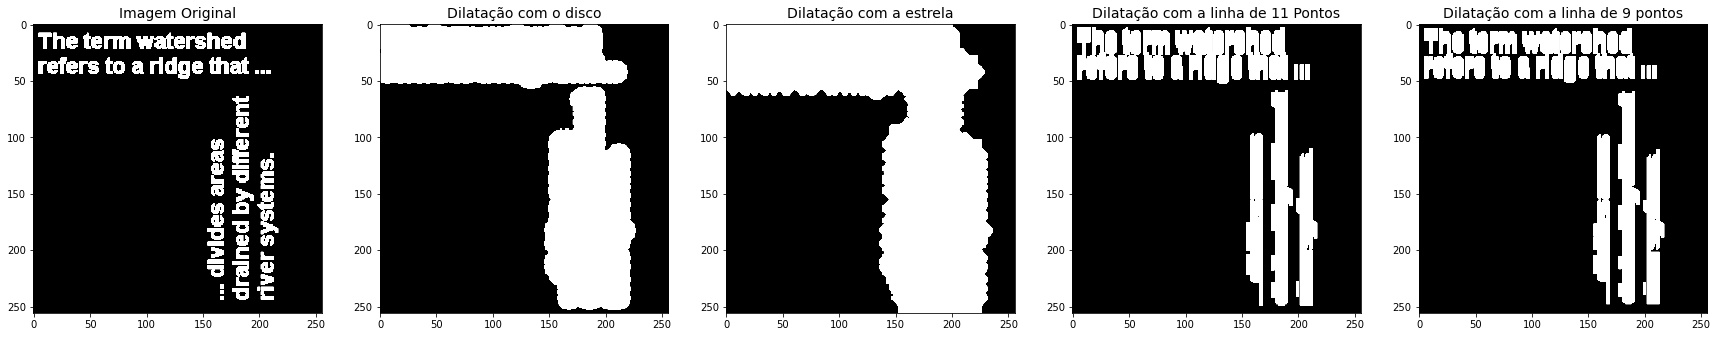

In [13]:
# IMPLEMENTE SEU CÓDIGO AQUI --> QUESTÃO 6

# IMPLEMENTE SEU CÓDIGO AQUI --> QUESTÃO 6
R = 9 #Raio do Disco
A = 13 #Dimensão pedida para a estrela

fig, axs = plt.subplots(nrows = 1, ncols = 5, figsize=(30, 20))

linha_V_11 = np.zeros((11,11), dtype = np.uint8) #colocando como linha definida para a linha 9
linha_V_11[:,5] = 1

linha_V_9 = np.zeros((9,9), dtype = np.uint8) #colocando como linha definida para a linha 9
linha_V_9[:,4] = 1

axs[0].imshow(img, cmap = 'gray') # Imagem text.tif
axs[0].imshow(img, vmin = 0, vmax = 1, cmap = "gray")
axs[0].set_title("Imagem Original", size = 14)

kernel = skimage.morphology.disk(R)
imgMod = cv2.dilate(img, kernel, 1) #imagem alterada pelo o kernel do disco

axs[1].imshow(imgMod, cmap = 'gray') #monstrando a imagem com alteração
axs[1].imshow(imgMod, vmin = 0, vmax = 1, cmap = "gray")
axs[1].set_title("Dilatação com o disco", size = 14)


kernel = skimage.morphology.star(A)
imgMod = cv2.dilate(img, kernel, 1) #imagem alterada pelo o kernel do estrela

axs[2].imshow(imgMod, cmap = 'gray') #monstrando a imagem com alteração
axs[2].imshow(imgMod, vmin = 0, vmax = 1, cmap = "gray")
axs[2].set_title("Dilatação com a estrela", size = 14)

kernel = linha_V_11
imgMod = cv2.dilate(img, kernel, 1) #imagem alterada pelo o kernel do linha_V_11

axs[3].imshow(imgMod, cmap = 'gray') #monstrando a imagem com alteração
axs[3].imshow(imgMod, vmin = 0, vmax = 1, cmap = "gray")
axs[3].set_title("Dilatação com a linha de 11 Pontos", size = 14)


kernel = linha_V_9
imgMod = cv2.dilate(img, kernel, 1) #imagem alterada pelo o kernel do linha_V_9

axs[4].imshow(imgMod, cmap = 'gray') #monstrando a imagem com alteração
axs[4].imshow(imgMod, vmin = 0, vmax = 1, cmap = "gray")
axs[4].set_title("Dilatação com a linha de 9 pontos", size = 14)

## <span style='color:green'>Respostas da Questão 6:</span>

* As dilatações efetuadas em imagens que possuiam uma área maior, geram maior deformação comparada a atuação das linhas criadas. Os kernels gerados, o que obteve a maior eficiência foi o da linha 99, trazendo uma maior eficiência e deixando ainda uma bem próximo de um texto legível.

## <span style='color:blue'>Questão 7: [Valor da Questão: 1.5][Taxa de acerto: x.x]</span>

* Realize a erosão na imagem "**wirebond_mask.tif**" com um elemento estruturante formado por um diamante de raio 6. Varie o tamanho (raio) do elemento estruturante para 4 e 8 e mostre os resultados. Comente os resultados encontrados.

Text(0.5, 1.0, 'Erosão pelo diamante de raio 8')

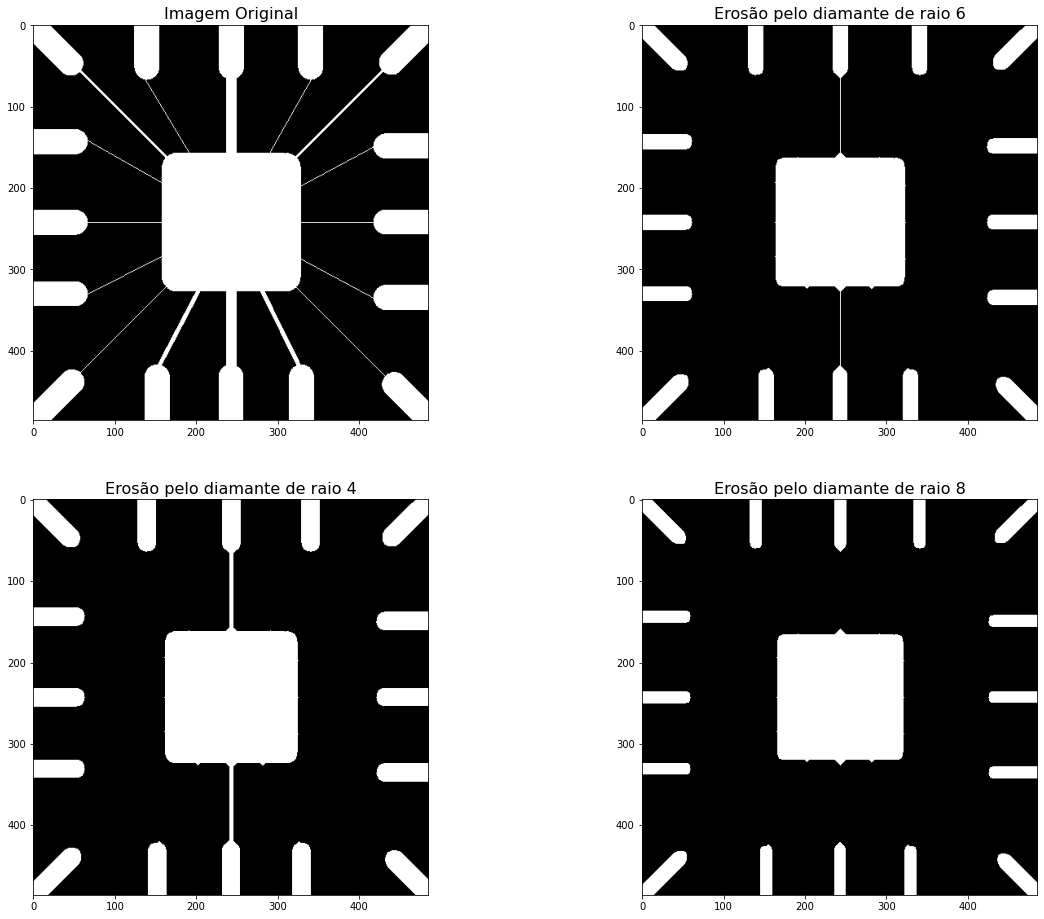

In [18]:
# IMPLEMENTE SEU CÓDIGO AQUI --> QUESTÃO 7

imgmW = cv2.imread(os.path.join(".", "imagens", "wirebond_mask.tif"), 0) #Importando a imagem
R = 6 #Definindo o tamanho do primeiro raio

fig, axs = plt.subplots(nrows = 2, ncols = 2, figsize=(20, 16))

kernel = skimage.morphology.diamond(R) #Definindo o kernel para o diamante de raio 6

imgmW_erode= cv2.erode(imgmW, kernel, 1) #Imagem definida pós erosão

axs[0][0].imshow(imgmW, cmap = 'gray')
axs[0][0].set_title("Imagem Original", size = 16)

axs[0][1].imshow(imgmW_erode, cmap = 'gray')
axs[0][1].set_title("Erosão pelo diamante de raio 6", size = 16)

R = 4 #Definindo o tamanho do segundo raio
kernel = skimage.morphology.diamond(R) #Definindo o novo raio para o Kernel
imgmW_erode = cv2.erode(imgmW, kernel, 1) #Imagem definida pós erosão

axs[1][0].imshow(imgmW_erode, cmap = 'gray') #Imprimindo o resultado
axs[1][0].set_title("Erosão pelo diamante de raio 4", size = 16)

R = 8 #Definindo o tamanho do terceiro raio
kernel = skimage.morphology.diamond(R) #Definindo o novo raio para o Kernel
imgmW_erode = cv2.erode(imgmW, kernel, 1) #Imagem definida pós erosão

axs[1][1].imshow(imgmW_erode, cmap = 'gray') #Imprimindo o resultado
axs[1][1].set_title("Erosão pelo diamante de raio 8", size = 16)

## <span style='color:green'>Respostas da Questão 7:</span>

* Notamos que ao efetuar o aumento do raio do diamante os traços que ficam na lateral e o quadrado central diminuem, também podemos notar que os traços que aparecem ligando os traços da lateral com o centro desaparecem na medida que aumenta o raio os traços diminuem.

### Abertura e Fechamento

A partir de um elemento estruturante é possível utilizar funções do OpenCV para realizar as transformações morfológicas de abertura e fechamento a partir de uma mesma função. Sua sintaxe é: 

* `dst_img = cv2.morphologyEx(src_img, FLAG, kernel)`       

* **Descrição:**
    * **dst_img** representa a imagem de saída;
    * **src_img** representa a imagem de entrada;
    * **kernel** representa o elemento estruturante;
    * **FLAG** é um parâmetro que indica a transformação realizada, pode ser:
        * **cv2.MORPH_OPEN** realiza uma operação de abertura;
        * **cv2.MORPH_CLOSE** realiza uma operação de fechamento;
        * **cv2.MORPH_GRADIENT** realiza uma operação de gradiente morfológico (diferença entre as versões dilatada e erodida de uma imagem);
        * **cv2.MORPH_TOPHAT** realiza uma operação de Tophat (diferença entre a imagem original e sua versão após abertura);
        * **cv2.MORPH_BLACKHAT** realiza uma operação de Blackhat (diferença entre a versão da imagem após fechamento e a original);

## <span style='color:blue'>Questão 8: [Valor da Questão: 1.0][Taxa de acerto: x.x]</span>

* Aplique os seguintes filtros morfológicos na imagem "**shapes.tif**". Comente os resultados encontrados em todos os itens acima. Utilize mais células se achar necessário.
    * Abertura, utilizando um elemento estruturante quadrado (square) de altura 10.
    * Fechamento, utilizando um elemento estruturante quadrado de altura 10.
    * Uma abertura seguida de um fechamento, um elemento estruturante quadrado de altura 10.
    * Repetir o item anterior variando a altura do elemento estruturante para 5 e depois para 15. Analise os resultados encontrados.

Text(0.5, 1.0, 'Abertura/ Fechamento H = 15')

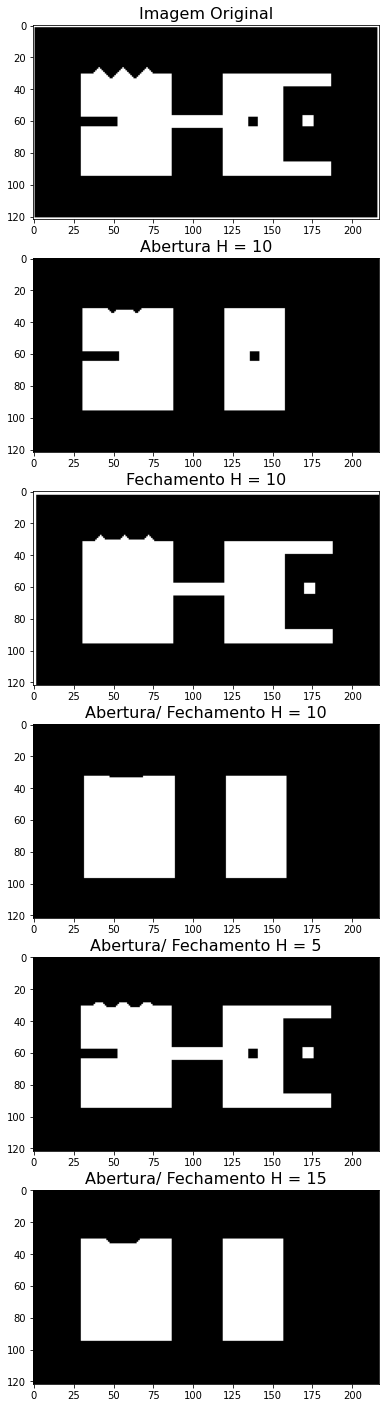

In [29]:
# IMPLEMENTE O SEU CÓDIGO AQUI --> QUESTÃO 7 (utilize mais células se achar necessário)

fig, axs = plt.subplots(nrows = 6, ncols = 1, figsize=(20, 25))

imshape = cv2.imread(os.path.join(".", "imagens", "shapes.tif"), 0)

H = 10
kernel = skimage.morphology.square(H) #Definindo o kernel

#FUNÇÃO PARA ABRIR IMAGEM
imshapeTa = cv2.morphologyEx(imshape, cv2.MORPH_OPEN, kernel)

#FUNÇÃO PARA FECHAR IMAGEM
imshapeTf = cv2.morphologyEx(imshape, cv2.MORPH_CLOSE, kernel)

imshapeT1 = cv2.morphologyEx(imshape, cv2.MORPH_OPEN, kernel)
imshapeT1 = cv2.morphologyEx(imshapeT1, cv2.MORPH_CLOSE, kernel)

#FUNÇÃO PARA MUDANÇA DE ALTURA, MAIS ABERTTURA E FECHAMENTO
H = 5
kernel = skimage.morphology.square(H) #Mudando o kernel para a nova altura

imshapeT2 = cv2.morphologyEx(imshape, cv2.MORPH_OPEN, kernel)
imshapeT2 = cv2.morphologyEx(imshapeT2, cv2.MORPH_CLOSE, kernel)

#FUNÇÃO PARA MUDANÇA DE ALTURA, MAIS ABERTTURA E FECHAMENTO
H = 15
kernel = skimage.morphology.square(H) #Mudando o kernel para a nova altura

imshapeT3 = cv2.morphologyEx(imshape, cv2.MORPH_OPEN, kernel)
imshapeT3 = cv2.morphologyEx(imshapeT3, cv2.MORPH_CLOSE, kernel)


axs[0].imshow(imshape, cmap = 'gray') 
axs[0].set_title("Imagem Original", size = 16)

axs[1].imshow(imshapeTa, cmap = 'gray') 
axs[1].set_title("Abertura H = 10", size = 16)

axs[2].imshow(imshapeTf, cmap = 'gray') 
axs[2].set_title("Fechamento H = 10", size = 16)

axs[3].imshow(imshapeT1, cmap = 'gray')
axs[3].set_title("Abertura/ Fechamento H = 10", size = 16)

axs[4].imshow(imshapeT2, cmap = 'gray') 
axs[4].set_title("Abertura/ Fechamento H = 5", size = 16)

axs[5].imshow(imshapeT3, cmap = 'gray') 
axs[5].set_title("Abertura/ Fechamento H = 15", size = 16)

## <span style='color:green'>Respostas da Questão 8:</span>

* Fica percepitivel os procedimentos de abertura e fechamento nas imagens.O processo de abertura e fechamento, gera para nós de forma evidente um processo de erosão e dilatação respectvamente, efetuando o emprego das duas ações ele permite uma melhor visualização de forma mais detalhada da borda que não acontece com a mesma imagem apenas com a mudança do H.

## <span style='color:blue'>Questão 9: [Valor da Questão: 1.0][Taxa de acerto: x.x]</span>

* Aplique os seguintes filtros morfológicos na imagem "**finger.jpg**". Comente os resultados encontrados em todos os itens.
    * Abertura, utilizando um elemento estruturante em formato de disco de raio 1.
    * Fechamento, utilizando um elemento estruturante em formato de disco de raio 1.
    * Uma abertura seguida de um fechamento com um elemento estruturante em formato de disco de raio 1.
    * Um fechamento seguido de uma abertura com um elemento estruturante em formato de disco de raio 1.

Text(0.5, 1.0, 'Disco de raio 1')

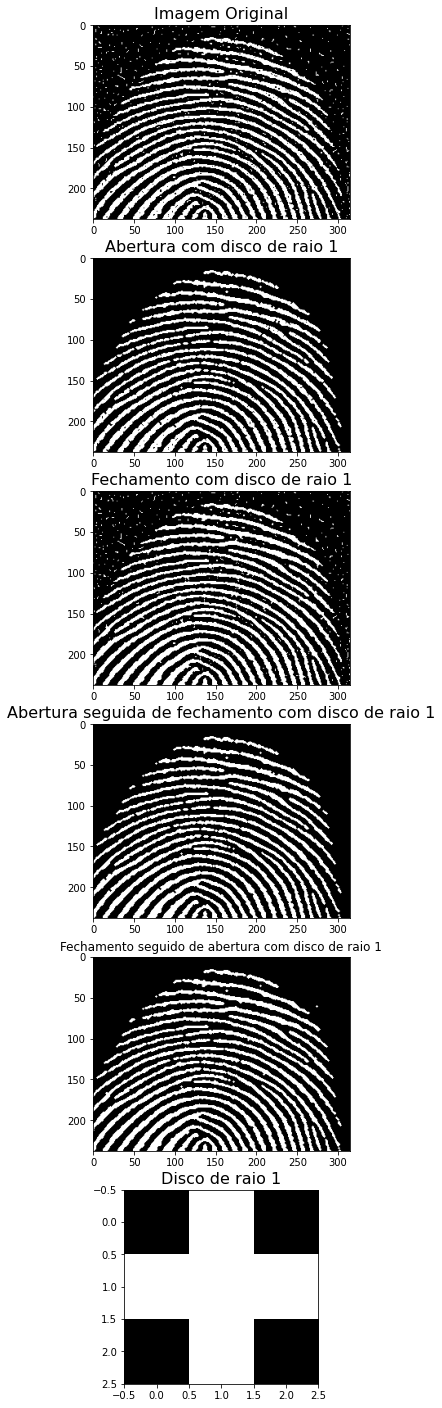

In [35]:
# IMPLEMENTE SEU CÓDIGO AQUI --> QUESTÃO 9

fig, axs = plt.subplots(nrows = 6, ncols = 1, figsize=(20, 25)) 

imgFi = cv2.imread(os.path.join(".", "imagens", "finger.jpg"), 0) 

R = 1 #Definição de Raio
kernel = skimage.morphology.disk(R) 

imgFi1 = cv2.morphologyEx(imgFi, cv2.MORPH_OPEN, kernel) #Definindo o imagem de saída - abertura

axs[0].imshow(imgFi, cmap = 'gray') #Plotando a imagem original
axs[0].set_title("Imagem Original", size = 16) #Título da imagem

axs[1].imshow(imgFi1, cmap = 'gray') #Plotando a imagem de saída da abertura
axs[1].set_title("Abertura com disco de raio 1", size = 16)#Título da imagem

imgFi1 = cv2.morphologyEx(imgFi, cv2.MORPH_CLOSE, kernel) #Fechamento sendo definida como principal

axs[2].imshow(imgFi1, cmap = 'gray') #Plotando a imagem de saída do fechamento 
axs[2].set_title("Fechamento com disco de raio 1", size = 16)

imgFi1 = cv2.morphologyEx(imgFi, cv2.MORPH_OPEN, kernel) #Abertura/Fechamento sendo definida
imgFi1 = cv2.morphologyEx(imgFi1, cv2.MORPH_CLOSE, kernel)

axs[3].imshow(imgFi1, cmap = 'gray') #plotando a imagem com a abertura e fechamento
axs[3].set_title("Abertura seguida de fechamento com disco de raio 1", size = 16)#Título da imagem

imgFi1 = cv2.morphologyEx(imgFi, cv2.MORPH_CLOSE, kernel) #Processo de fechamento e abertura
imgFi1 = cv2.morphologyEx(imgFi1, cv2.MORPH_OPEN, kernel)

axs[4].imshow(imgFi1, cmap = 'gray') #Plotando a imagem de fechamento e abertura
axs[4].set_title("Fechamento seguido de abertura com disco de raio 1")#Título da imagem

axs [5].imshow(kernel, cmap = 'gray') #Plotando o disco de raio 1
axs [5].set_title("Disco de raio 1", size = 16)#Título da imagem

## <span style='color:green'>Respostas da Questão 9:</span>

* Ao longo do procedimento podemos ver que ao utilizar apenas uma das maáscaras seja de abertura ou de fechamento encontramos ainda algum detalhe que não nos entrega a imagem perfeita, seja um "borrão" nas imagens geradas apenas por fechamento, seja pela a interferência em uma parte que se faz importante para análise, como as rupturas na digital. porém ao misturarmos as duas operações seguidas de abertura e fechamento, entrega a melhor imagem entre todos os testes, o processo inverso entrega uma imagem boa, porém com alguns detalhes de falha perceptiveis, até mais do que as encontradas na imagem que possui apenas o filtro de abertura.

![gif2](https://user-images.githubusercontent.com/58775072/142712675-08fa8843-9a5e-4109-a94a-8ca2d60e4fa8.gif)